# MVP ATL 2025 - EDA Operativo + Baseline ML

Notebook orientado al MVP de prediccion de demoras en ATL (2025), usando:
- Dataset maestro de vuelos BTS con ATL como ORIGIN o DEST,
- Clima IEM en ORIGIN y DEST,
- Preguntas operativas de negocio para efecto domino de retrasos.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, classification_report

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH = Path('/Users/mateopappalardo/Downloads/tesis_local/dataset_maestro_ATL_2025_BTS_IEM_ORIG_DEST.csv')
df = pd.read_csv(DATA_PATH, low_memory=False)

print('Rows:', len(df))
print('Cols:', len(df.columns))
display(df.head(3))

Rows: 185521
Cols: 65


,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,DEP_TIME,ARR_TIME,DEP_DELAY,ARR_DELAY,DEP_DELAY_NEW,ARR_DELAY_NEW,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FLOW_ATL,PAR_AIRPORT,CRS_DEP_MIN,DEP_LOCAL_DT,EVENT_ORIGIN_UTC,EVENT_DEST_UTC,ORIG_WX_VALID_UTC,ORIG_WX_TMPC,ORIG_WX_DWPC,ORIG_WX_RELH,ORIG_WX_DRCT,ORIG_WX_SKNT,ORIG_WX_ALTI,ORIG_WX_P01M,ORIG_WX_VSBY,ORIG_WX_GUST,ORIG_WX_CODES,ORIG_WX_PRECIP_FLAG,ORIG_WX_LOW_VIS_FLAG,ORIG_WX_STRONG_WIND_FLAG,ORIG_WX_MATCH_GAP_MIN,DEST_WX_VALID_UTC,DEST_WX_TMPC,DEST_WX_DWPC,DEST_WX_RELH,DEST_WX_DRCT,DEST_WX_SKNT,DEST_WX_ALTI,DEST_WX_P01M,DEST_WX_VSBY,DEST_WX_GUST,DEST_WX_CODES,DEST_WX_PRECIP_FLAG,DEST_WX_LOW_VIS_FLAG,DEST_WX_STRONG_WIND_FLAG,DEST_WX_MATCH_GAP_MIN
0,2025,1,1,3,2025-01-01,DL,N555NW,1545,TPA,ATL,600,732,555.0,722.0,0.0,0.0,0.0,0.0,0.0,0.0,92.0,87.0,66.0,406.0,NaN,NaN,NaN,NaN,NaN,ARR_TO_ATL,TPA,360.0,2025-01-01 06:00:00,2025-01-01 11:00:00,2025-01-01 12:32:00,2025-01-01 10:53:00,18.89,17.78,93.26,320.0,6.0,30.04,0.0,9.0,NaN,M,False,False,False,7.0,2025-01-01 12:52:00,4.44,0.56,75.84,300.0,10.0,30.11,0.0,10.0,NaN,M,False,False,False,20.0
1,2025,1,1,3,2025-01-01,DL,N667DN,1494,MCO,ATL,600,735,558.0,731.0,0.0,0.0,0.0,0.0,0.0,0.0,95.0,93.0,62.0,404.0,NaN,NaN,NaN,NaN,NaN,ARR_TO_ATL,MCO,360.0,2025-01-01 06:00:00,2025-01-01 11:00:00,2025-01-01 12:35:00,2025-01-01 10:53:00,18.00,18.00,100.00,280.0,3.0,30.03,0.0,6.0,NaN,BR,False,False,False,7.0,2025-01-01 12:52:00,4.44,0.56,75.84,300.0,10.0,30.11,0.0,10.0,NaN,M,False,False,False,17.0
2,2025,1,1,3,2025-01-01,DL,N362DN,1269,PHL,ATL,538,800,532.0,732.0,0.0,0.0,0.0,0.0,0.0,0.0,142.0,120.0,106.0,666.0,NaN,NaN,NaN,NaN,NaN,ARR_TO_ATL,PHL,338.0,2025-01-01 05:38:00,2025-01-01 10:38:00,2025-01-01 13:00:00,2025-01-01 10:24:00,7.78,6.67,92.68,230.0,7.0,29.54,0.0,7.0,NaN,M,False,False,False,14.0,2025-01-01 12:52:00,4.44,0.56,75.84,300.0,10.0,30.11,0.0,10.0,NaN,M,False,False,False,8.0


## 1) Preparacion operativa de variables ATL-side

Normalizamos los campos para siempre mirar delay y clima del lado ATL del evento:
- si ATL es ORIGIN -> usamos DEP_DELAY y ORIG_WX_*
- si ATL es DEST -> usamos ARR_DELAY y DEST_WX_*

In [2]:
for col in ['FL_DATE', 'EVENT_ORIGIN_UTC', 'EVENT_DEST_UTC', 'ORIG_WX_VALID_UTC', 'DEST_WX_VALID_UTC']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

num_cols = [
    'DEP_DELAY', 'ARR_DELAY', 'LATE_AIRCRAFT_DELAY', 'CARRIER_DELAY', 'WEATHER_DELAY',
    'NAS_DELAY', 'SECURITY_DELAY', 'CRS_DEP_TIME', 'CRS_ELAPSED_TIME',
    'ORIG_WX_VSBY', 'DEST_WX_VSBY', 'ORIG_WX_P01M', 'DEST_WX_P01M',
    'ORIG_WX_SKNT', 'DEST_WX_SKNT', 'ORIG_WX_GUST', 'DEST_WX_GUST'
]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

is_dep = df['FLOW_ATL'].eq('DEP_FROM_ATL')
df['ATL_EVENT_UTC'] = pd.to_datetime(np.where(is_dep, df['EVENT_ORIGIN_UTC'], df['EVENT_DEST_UTC']), errors='coerce')
df['DELAY_ATL_MIN'] = np.where(is_dep, df['DEP_DELAY'], df['ARR_DELAY'])
df['SEV45'] = df['DELAY_ATL_MIN'] > 45
df['CRIT90'] = df['DELAY_ATL_MIN'] > 90

df['ATL_WX_VSBY'] = np.where(is_dep, df['ORIG_WX_VSBY'], df['DEST_WX_VSBY'])
df['ATL_WX_P01M'] = np.where(is_dep, df['ORIG_WX_P01M'], df['DEST_WX_P01M'])
df['ATL_WX_SKNT'] = np.where(is_dep, df['ORIG_WX_SKNT'], df['DEST_WX_SKNT'])
df['ATL_WX_GUST'] = np.where(is_dep, df['ORIG_WX_GUST'], df['DEST_WX_GUST'])
df['ATL_WX_CODES'] = np.where(is_dep, df['ORIG_WX_CODES'], df['DEST_WX_CODES'])

df['ATL_WX_LOW_VIS'] = np.where(is_dep, df['ORIG_WX_LOW_VIS_FLAG'], df['DEST_WX_LOW_VIS_FLAG'])
df['ATL_WX_STRONG_WIND'] = np.where(is_dep, df['ORIG_WX_STRONG_WIND_FLAG'], df['DEST_WX_STRONG_WIND_FLAG'])
for c in ['ATL_WX_LOW_VIS', 'ATL_WX_STRONG_WIND']:
    df[c] = df[c].astype('string').str.lower().map({'true': 1, 'false': 0})

df['TS_FLAG'] = df['ATL_WX_CODES'].astype('string').str.contains('TS', case=False, na=False)
df['ATL_WX_PRECIP'] = pd.to_numeric(df['ATL_WX_P01M'], errors='coerce').fillna(0)

print('Eventos ATL con delay valido:', int(df['DELAY_ATL_MIN'].notna().sum()))
print('Share CRIT90:', round(df['CRIT90'].mean() * 100, 2), '%')
print('Share SEV45:', round(df['SEV45'].mean() * 100, 2), '%')

Eventos ATL con delay valido: 182014
Share CRIT90: 6.0 %
Share SEV45: 12.58 %


## 2) Elasticidad Logistica (Efecto Cascada)

Calculamos turnaround buffer por Tail_Number y composicion de retrasos criticos (>90 min).

Turnaround pairs: 55455
Tail Numbers: 3964
Avg turnaround buffer (min): 186.07
P25/P50/P75: [np.float64(10.0), np.float64(56.0), np.float64(369.5)]
Critical >90 count: 11137
Critical pure LateAircraft (%): 12.83
Critical with local causes (%): 86.46


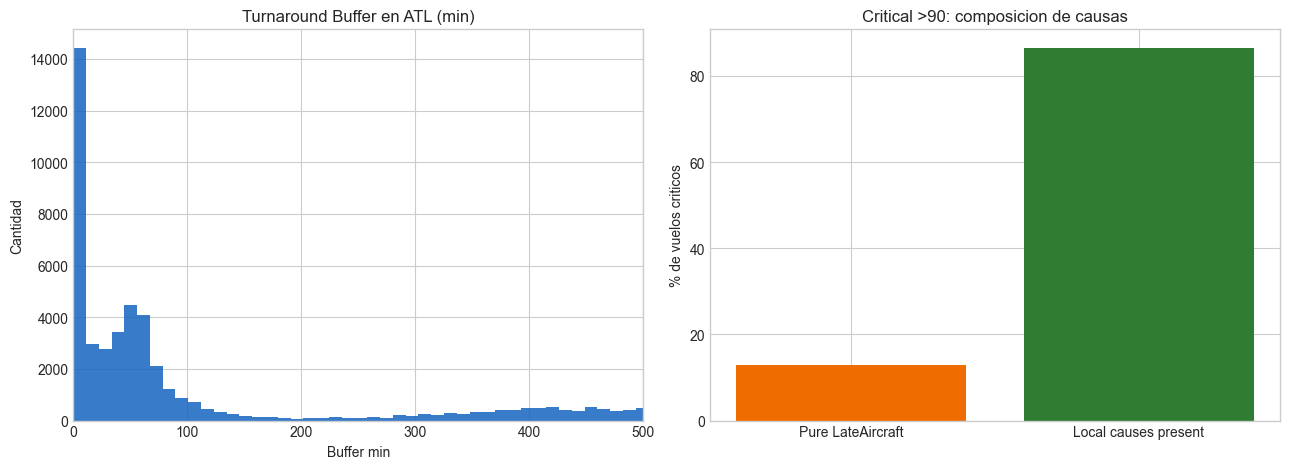

In [3]:
arr = df[df['DEST'].eq('ATL')][['TAIL_NUM', 'EVENT_DEST_UTC', 'EVENT_ORIGIN_UTC', 'ACTUAL_ELAPSED_TIME']].copy()
arr = arr.rename(columns={'EVENT_DEST_UTC': 'SCHED_ARR_ATL_UTC'})
arr['ACT_ARR_ATL_UTC'] = arr['EVENT_ORIGIN_UTC'] + pd.to_timedelta(pd.to_numeric(arr['ACTUAL_ELAPSED_TIME'], errors='coerce'), unit='m')

dep = df[df['ORIGIN'].eq('ATL')][['TAIL_NUM', 'EVENT_ORIGIN_UTC']].copy()
dep = dep.rename(columns={'EVENT_ORIGIN_UTC': 'SCHED_DEP_ATL_UTC'})

turn_parts = []
for tail in sorted(arr['TAIL_NUM'].dropna().astype(str).unique()):
    a = arr[arr['TAIL_NUM'].astype(str).eq(tail)].sort_values('SCHED_ARR_ATL_UTC')
    d = dep[dep['TAIL_NUM'].astype(str).eq(tail)].sort_values('SCHED_DEP_ATL_UTC')
    if a.empty or d.empty:
        continue
    m = pd.merge_asof(
        a, d,
        left_on='SCHED_ARR_ATL_UTC',
        right_on='SCHED_DEP_ATL_UTC',
        direction='forward',
        tolerance=pd.Timedelta('36h')
    )
    m['TAIL_NUM'] = tail
    turn_parts.append(m)

turn = pd.concat(turn_parts, ignore_index=True) if turn_parts else pd.DataFrame()

turn['sched_ground_min'] = (turn['SCHED_DEP_ATL_UTC'] - turn['SCHED_ARR_ATL_UTC']).dt.total_seconds() / 60
turn = turn[(turn['sched_ground_min'] >= 0) & (turn['sched_ground_min'] <= 900)]

tail_min_sched = turn.groupby('TAIL_NUM')['sched_ground_min'].min().rename('tail_min_ground_sched')
turn = turn.join(tail_min_sched, on='TAIL_NUM')
turn['turnaround_buffer_min'] = turn['sched_ground_min'] - turn['tail_min_ground_sched']

crit = df[df['CRIT90']].copy()
for c in ['LATE_AIRCRAFT_DELAY', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY']:
    crit[c] = pd.to_numeric(crit[c], errors='coerce').fillna(0)
crit['late_pure'] = (crit['LATE_AIRCRAFT_DELAY'] > 0) & (crit[['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY']].sum(axis=1) == 0)
crit['local_any'] = crit[['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY']].sum(axis=1) > 0

print('Turnaround pairs:', len(turn))
print('Tail Numbers:', turn['TAIL_NUM'].nunique())
print('Avg turnaround buffer (min):', round(turn['turnaround_buffer_min'].mean(), 2))
print('P25/P50/P75:', [round(turn['turnaround_buffer_min'].quantile(q), 2) for q in [0.25, 0.5, 0.75]])
print('Critical >90 count:', len(crit))
print('Critical pure LateAircraft (%):', round(crit['late_pure'].mean() * 100, 2))
print('Critical with local causes (%):', round(crit['local_any'].mean() * 100, 2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(turn['turnaround_buffer_min'].dropna(), bins=80, color='#1565c0', alpha=0.85)
axes[0].set_title('Turnaround Buffer en ATL (min)')
axes[0].set_xlabel('Buffer min')
axes[0].set_ylabel('Cantidad')
axes[0].set_xlim(0, 500)

comp = pd.Series({
    'Pure LateAircraft': crit['late_pure'].mean() * 100,
    'Local causes present': crit['local_any'].mean() * 100
})
axes[1].bar(comp.index, comp.values, color=['#ef6c00', '#2e7d32'])
axes[1].set_title('Critical >90: composicion de causas')
axes[1].set_ylabel('% de vuelos criticos')

plt.tight_layout()
plt.show()

## 3) Umbrales Climaticos Locales

- Punto de quiebre de visibilidad vs delay >45
- Tiempo de recuperacion tras eventos TS

Visibility breakpoint (miles): 0.0
Baseline non-TS sev45 (%): 12.23
TS recovery median (h): 6.25
TS episodes measured: 79


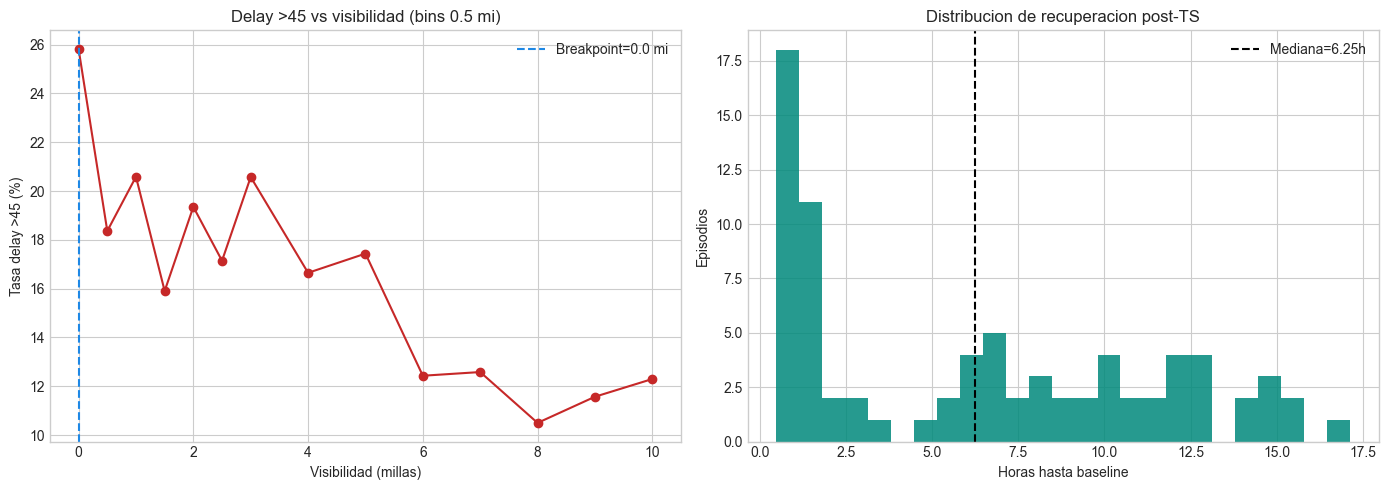

In [4]:
vis = df[['ATL_WX_VSBY', 'SEV45']].dropna().copy()
vis = vis[(vis['ATL_WX_VSBY'] >= 0) & (vis['ATL_WX_VSBY'] <= 10)]
vis['vsby_bin'] = np.floor(vis['ATL_WX_VSBY'] * 2) / 2
vis_g = vis.groupby('vsby_bin').agg(n=('SEV45', 'size'), rate45=('SEV45', 'mean')).reset_index().sort_values('vsby_bin')
vis_g = vis_g[vis_g['n'] >= 200]
vis_g['rate45_pct'] = vis_g['rate45'] * 100
vis_g['delta_to_next'] = vis_g['rate45_pct'].diff(-1)
cand = vis_g[vis_g['vsby_bin'] <= 5]
breakpoint = cand.loc[cand['delta_to_next'].idxmax(), 'vsby_bin'] if len(cand) else vis_g.loc[vis_g['rate45_pct'].idxmax(), 'vsby_bin']

flt = df[['ATL_EVENT_UTC', 'SEV45', 'TS_FLAG']].dropna().sort_values('ATL_EVENT_UTC').copy()
baseline_non_ts = flt.loc[~flt['TS_FLAG'], 'SEV45'].mean()

storm = flt[flt['TS_FLAG']].copy()
recovery_hours = []
if len(storm) > 0:
    storm['gap_h'] = storm['ATL_EVENT_UTC'].diff().dt.total_seconds().div(3600).fillna(0)
    storm['cluster'] = (storm['gap_h'] > 2).cumsum()
    ends = storm.groupby('cluster')['ATL_EVENT_UTC'].max().tolist()
    for end_t in ends:
        post = flt[flt['ATL_EVENT_UTC'] > end_t].copy()
        if len(post) < 30:
            continue
        r = post['SEV45'].rolling(20, min_periods=20).mean()
        hit = post.loc[r <= baseline_non_ts + 0.01, 'ATL_EVENT_UTC']
        if len(hit):
            recovery_hours.append((hit.iloc[0] - end_t).total_seconds() / 3600)

print('Visibility breakpoint (miles):', breakpoint)
print('Baseline non-TS sev45 (%):', round(baseline_non_ts * 100, 2))
print('TS recovery median (h):', round(float(np.median(recovery_hours)), 2) if recovery_hours else None)
print('TS episodes measured:', len(recovery_hours))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(vis_g['vsby_bin'], vis_g['rate45_pct'], marker='o', color='#c62828')
axes[0].axvline(breakpoint, color='#1e88e5', linestyle='--', label=f'Breakpoint={breakpoint} mi')
axes[0].set_title('Delay >45 vs visibilidad (bins 0.5 mi)')
axes[0].set_xlabel('Visibilidad (millas)')
axes[0].set_ylabel('Tasa delay >45 (%)')
axes[0].legend()

if recovery_hours:
    axes[1].hist(recovery_hours, bins=25, color='#00897b', alpha=0.85)
    axes[1].axvline(np.median(recovery_hours), color='black', linestyle='--', label=f'Mediana={np.median(recovery_hours):.2f}h')
    axes[1].legend()
axes[1].set_title('Distribucion de recuperacion post-TS')
axes[1].set_xlabel('Horas hasta baseline')
axes[1].set_ylabel('Episodios')

plt.tight_layout()
plt.show()

## 4) Saturacion y Hora de No Retorno

Buscamos en que bloque horario un delay leve (15-44) tiene mayor chance de arrastrar al siguiente vuelo del mismo Tail a >90 min.

Top horas de no retorno:


,BANK_2H,n,p_next_crit
1,6,679,8.10
4,12,1243,7.08
9,22,1010,7.03
6,16,1798,6.90
2,8,1150,6.87
5,14,1775,6.70
3,10,1492,6.50
0,4,109,6.42
7,18,2046,5.87
8,20,1563,5.76


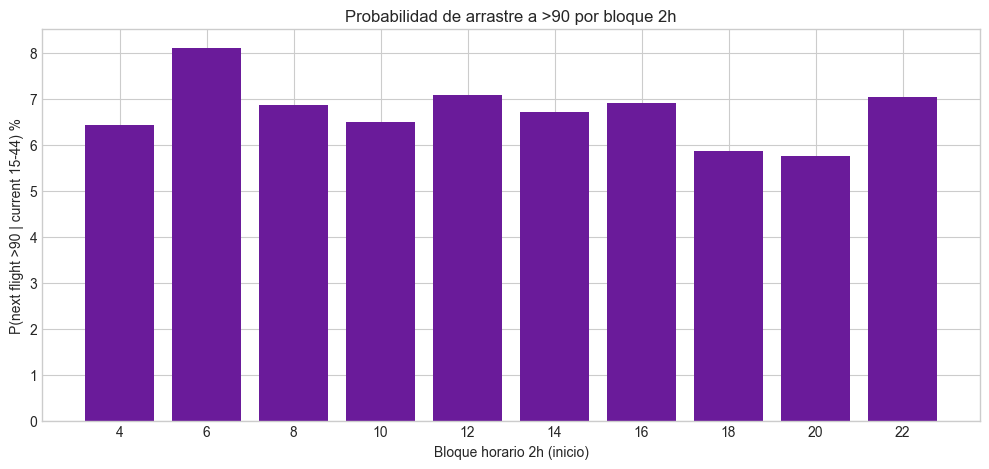

In [5]:
dep_atl = df[df['FLOW_ATL'].eq('DEP_FROM_ATL')].copy().sort_values(['TAIL_NUM', 'EVENT_ORIGIN_UTC'])
dep_atl['NEXT_DEP_DELAY'] = dep_atl.groupby('TAIL_NUM')['DEP_DELAY'].shift(-1)
dep_atl['MILD_15_44'] = dep_atl['DEP_DELAY'].between(15, 44, inclusive='both')
dep_atl['NEXT_CRIT90'] = dep_atl['NEXT_DEP_DELAY'] > 90
dep_atl['DEP_HOUR'] = (pd.to_numeric(dep_atl['CRS_DEP_TIME'], errors='coerce') // 100).astype('float')
dep_atl['BANK_2H'] = (dep_atl['DEP_HOUR'] // 2 * 2).astype('Int64')

no_return = dep_atl[dep_atl['MILD_15_44'] & dep_atl['BANK_2H'].notna()].groupby('BANK_2H').agg(
    n=('NEXT_CRIT90', 'size'),
    p_next_crit=('NEXT_CRIT90', 'mean')
).reset_index()
no_return = no_return[no_return['n'] >= 30].sort_values('p_next_crit', ascending=False)

print('Top horas de no retorno:')
display(no_return.head(10).assign(p_next_crit=lambda x: (x['p_next_crit'] * 100).round(2)))

fig, ax = plt.subplots(figsize=(10, 4.8))
plot_nr = no_return.sort_values('BANK_2H')
ax.bar(plot_nr['BANK_2H'].astype(str), plot_nr['p_next_crit'] * 100, color='#6a1b9a')
ax.set_title('Probabilidad de arrastre a >90 por bloque 2h')
ax.set_xlabel('Bloque horario 2h (inicio)')
ax.set_ylabel('P(next flight >90 | current 15-44) %')
plt.tight_layout()
plt.show()

## 5) Resiliencia por Aerolinea (DL vs Low Cost)

Comparamos tiempos de recuperacion a puntualidad normal despues de eventos climaticos adversos.

DL baseline on-time <=15 (%): 76.72
LCC baseline on-time <=15 (%): 69.78
DL recovery median (h): 7.77 episodes: 177
LCC recovery median (h): 10.63 episodes: 179
Delta LCC-DL (h): 2.87


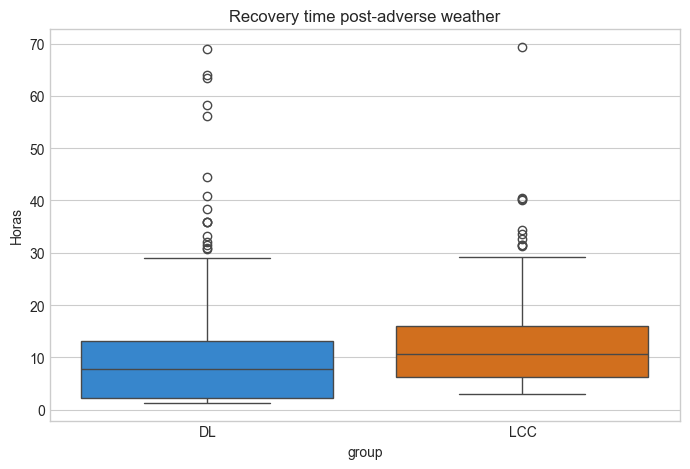

In [6]:
df['ADVERSE'] = df['TS_FLAG'] | (df['ATL_WX_LOW_VIS'] == 1) | (df['ATL_WX_PRECIP'] >= 0.05)
df['ON_TIME15'] = df['DELAY_ATL_MIN'] <= 15

carrier_df = df[['ATL_EVENT_UTC', 'OP_CARRIER', 'ADVERSE', 'ON_TIME15']].dropna().copy().sort_values('ATL_EVENT_UTC')
carrier_df['OP_CARRIER'] = carrier_df['OP_CARRIER'].astype('string').str.upper()

dl = carrier_df[carrier_df['OP_CARRIER'].eq('DL')].copy()
lcc_codes = {'WN', 'NK', 'F9', 'G4', 'B6', 'SY'}
lcc = carrier_df[carrier_df['OP_CARRIER'].isin(lcc_codes)].copy()

def recovery_stats(group):
    if group.empty:
        return np.nan, np.nan, []
    baseline = group.loc[~group['ADVERSE'], 'ON_TIME15'].mean()
    adverse = group[group['ADVERSE']].copy()
    if adverse.empty:
        return baseline, np.nan, []
    adverse['gap_h'] = adverse['ATL_EVENT_UTC'].diff().dt.total_seconds().div(3600).fillna(0)
    adverse['cluster'] = (adverse['gap_h'] > 2).cumsum()
    rec = []
    ends = adverse.groupby('cluster')['ATL_EVENT_UTC'].max().tolist()
    for end_t in ends:
        post = group[group['ATL_EVENT_UTC'] > end_t].copy()
        if len(post) < 40:
            continue
        roll = post['ON_TIME15'].rolling(30, min_periods=30).mean()
        hit = post.loc[roll >= baseline - 0.01, 'ATL_EVENT_UTC']
        if len(hit):
            rec.append((hit.iloc[0] - end_t).total_seconds() / 3600)
    return baseline, (np.median(rec) if rec else np.nan), rec

base_dl, rec_dl, rec_series_dl = recovery_stats(dl)
base_lcc, rec_lcc, rec_series_lcc = recovery_stats(lcc)

print('DL baseline on-time <=15 (%):', round(base_dl * 100, 2) if pd.notna(base_dl) else None)
print('LCC baseline on-time <=15 (%):', round(base_lcc * 100, 2) if pd.notna(base_lcc) else None)
print('DL recovery median (h):', round(rec_dl, 2) if pd.notna(rec_dl) else None, 'episodes:', len(rec_series_dl))
print('LCC recovery median (h):', round(rec_lcc, 2) if pd.notna(rec_lcc) else None, 'episodes:', len(rec_series_lcc))
if pd.notna(rec_dl) and pd.notna(rec_lcc):
    print('Delta LCC-DL (h):', round(rec_lcc - rec_dl, 2))

plot_data = []
if rec_series_dl:
    plot_data.append(pd.DataFrame({'group': 'DL', 'hours': rec_series_dl}))
if rec_series_lcc:
    plot_data.append(pd.DataFrame({'group': 'LCC', 'hours': rec_series_lcc}))
if plot_data:
    rec_plot = pd.concat(plot_data, ignore_index=True)
    fig, ax = plt.subplots(figsize=(7, 4.8))
    sns.boxplot(data=rec_plot, x='group', y='hours', ax=ax, palette=['#1e88e5', '#ef6c00'])
    ax.set_title('Recovery time post-adverse weather')
    ax.set_ylabel('Horas')
    plt.tight_layout()
    plt.show()

## 6) Correlaciones e Insights

Calculamos matrices Pearson y Spearman para validar la señal de clima y severidad.

Pearson vs DELAY_ATL_MIN:


,pearson
DELAY_ATL_MIN,1.000000
CRIT90,0.736936
SEV45,0.678196
ATL_WX_P01M,0.070462
ATL_WX_LOW_VIS,0.043952
ATL_WX_STRONG_WIND,0.040646
ATL_WX_VSBY,-0.052459


Spearman vs SEV45:


,spearman
SEV45,1.000000
CRIT90,0.666179
DELAY_ATL_MIN,0.626395
ATL_WX_P01M,0.065312
ATL_WX_STRONG_WIND,0.040374
ATL_WX_LOW_VIS,0.035063
ATL_WX_VSBY,-0.024009


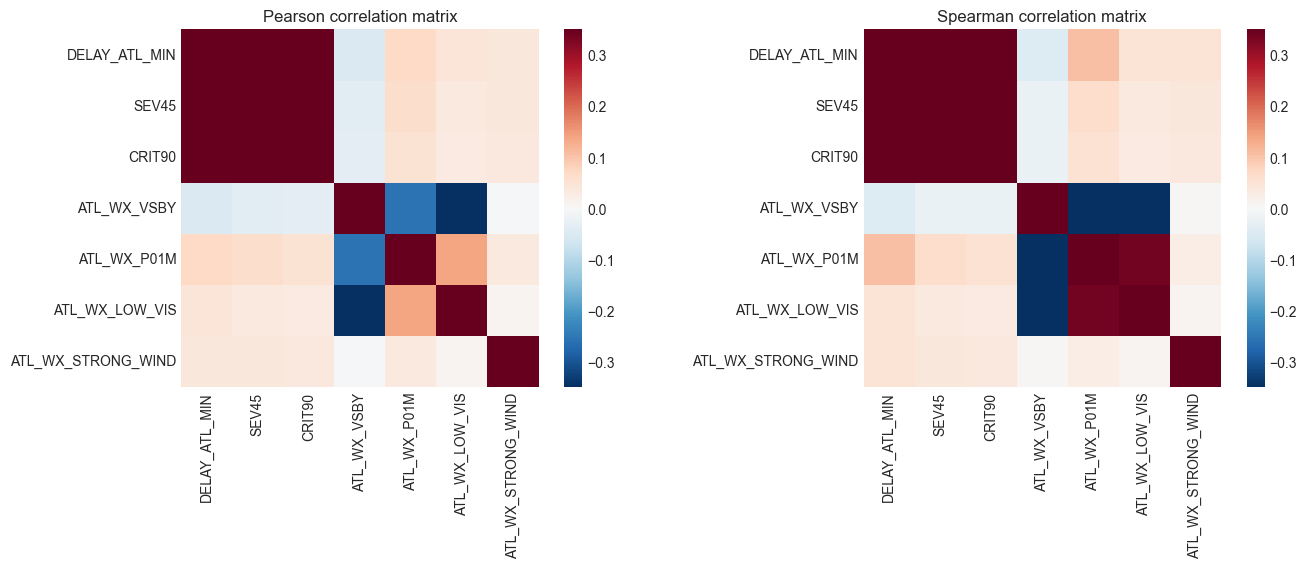

In [7]:
corr_df = df[['DELAY_ATL_MIN', 'SEV45', 'CRIT90', 'ATL_WX_VSBY', 'ATL_WX_P01M', 'ATL_WX_LOW_VIS', 'ATL_WX_STRONG_WIND']].copy()
for c in ['SEV45', 'CRIT90', 'ATL_WX_LOW_VIS', 'ATL_WX_STRONG_WIND']:
    corr_df[c] = corr_df[c].astype(float)

pear = corr_df.corr(method='pearson')
spear = corr_df.corr(method='spearman')

print('Pearson vs DELAY_ATL_MIN:')
display(pear['DELAY_ATL_MIN'].sort_values(ascending=False).to_frame('pearson'))
print('Spearman vs SEV45:')
display(spear['SEV45'].sort_values(ascending=False).to_frame('spearman'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(pear, cmap='RdBu_r', center=0, vmin=-0.35, vmax=0.35, square=True, ax=axes[0])
axes[0].set_title('Pearson correlation matrix')
sns.heatmap(spear, cmap='RdBu_r', center=0, vmin=-0.35, vmax=0.35, square=True, ax=axes[1])
axes[1].set_title('Spearman correlation matrix')
plt.tight_layout()
plt.show()

## 7) Feature Engineering Candidate Set

Propuesta de variables para el predictor de efecto domino en ATL.

In [8]:
feature_catalog = pd.DataFrame([
    {'feature': 'dep_bank_2h', 'tipo': 'temporal', 'uso': 'captura saturacion por banco horario'},
    {'feature': 'tail_prev_delay', 'tipo': 'cascada', 'uso': 'efecto domino intra-avion'},
    {'feature': 'tail_prev_crit90', 'tipo': 'cascada', 'uso': 'estado critico previo'},
    {'feature': 'turnaround_buffer_tail_sched', 'tipo': 'elasticidad', 'uso': 'margen operativo por cola'},
    {'feature': 'ATL_WX_VSBY', 'tipo': 'clima', 'uso': 'umbral visibilidad'},
    {'feature': 'ATL_WX_P01M', 'tipo': 'clima', 'uso': 'intensidad precip'},
    {'feature': 'TS_FLAG', 'tipo': 'clima', 'uso': 'evento de tormenta'},
    {'feature': 'ATL_WX_LOW_VIS', 'tipo': 'clima', 'uso': 'flag de bajo techo/visibilidad'},
    {'feature': 'ATL_WX_STRONG_WIND', 'tipo': 'clima', 'uso': 'flag de viento fuerte'},
    {'feature': 'carrier_baseline_ontime', 'tipo': 'carrier', 'uso': 'resiliencia por aerolinea'},
    {'feature': 'flow_atl', 'tipo': 'network', 'uso': 'diferenciar salida vs llegada ATL'},
    {'feature': 'par_airport', 'tipo': 'network', 'uso': 'contexto del nodo par'},
])
display(feature_catalog)

,feature,tipo,uso
0,dep_bank_2h,temporal,captura saturacion por banco horario
1,tail_prev_delay,cascada,efecto domino intra-avion
2,tail_prev_crit90,cascada,estado critico previo
3,turnaround_buffer_tail_sched,elasticidad,margen operativo por cola
4,ATL_WX_VSBY,clima,umbral visibilidad
5,ATL_WX_P01M,clima,intensidad precip
6,TS_FLAG,clima,evento de tormenta
7,ATL_WX_LOW_VIS,clima,flag de bajo techo/visibilidad
8,ATL_WX_STRONG_WIND,clima,flag de viento fuerte
9,carrier_baseline_ontime,carrier,resiliencia por aerolinea


## 8) Baseline ML (Temporal Split)

Entrenamos un baseline multiclase (0, 1, 2, 3) con split temporal:
- Train: hasta 2025-09-30
- Validation: 2025-10-01 a 2025-11-30
- Test: diciembre 2025

Modelo objetivo: XGBoost si esta disponible, fallback a GradientBoosting de sklearn.

In [9]:
model_df = df.copy()

model_df['TARGET_4C'] = np.select(
    [
        model_df['DELAY_ATL_MIN'] <= 15,
        model_df['DELAY_ATL_MIN'].between(15, 44, inclusive='right'),
        model_df['DELAY_ATL_MIN'].between(45, 89, inclusive='both'),
        model_df['DELAY_ATL_MIN'] > 89
    ],
    [0, 1, 2, 3],
    default=np.nan
)

dep_seq = model_df[model_df['FLOW_ATL'].eq('DEP_FROM_ATL')].copy().sort_values(['TAIL_NUM', 'ATL_EVENT_UTC'])
dep_seq['tail_prev_delay'] = dep_seq.groupby('TAIL_NUM')['DEP_DELAY'].shift(1)
dep_seq['tail_prev_crit90'] = (dep_seq.groupby('TAIL_NUM')['DEP_DELAY'].shift(1) > 90).astype(float)
model_df = model_df.merge(dep_seq[['TAIL_NUM', 'ATL_EVENT_UTC', 'tail_prev_delay', 'tail_prev_crit90']], on=['TAIL_NUM', 'ATL_EVENT_UTC'], how='left')

model_df['dep_hour'] = (pd.to_numeric(model_df['CRS_DEP_TIME'], errors='coerce') // 100)
model_df['dep_bank_2h'] = (model_df['dep_hour'] // 2 * 2).astype('Int64').astype('string')

model_df['ATL_WX_VSBY_BUCKET'] = pd.cut(
    model_df['ATL_WX_VSBY'],
    bins=[-0.1, 1, 3, 6, 20],
    labels=['lt1', '1to3', '3to6', 'ge6']
)
model_df['ATL_WX_PRECIP_BUCKET'] = pd.cut(
    model_df['ATL_WX_P01M'].fillna(0),
    bins=[-0.001, 0, 0.05, 0.2, 10],
    labels=['none', 'trace_light', 'light', 'moderate_plus']
)

feat_num = ['ATL_WX_VSBY', 'ATL_WX_P01M', 'ATL_WX_SKNT', 'ATL_WX_GUST', 'tail_prev_delay']
feat_cat = ['OP_CARRIER', 'FLOW_ATL', 'PAR_AIRPORT', 'dep_bank_2h', 'ATL_WX_VSBY_BUCKET', 'ATL_WX_PRECIP_BUCKET']
feat_bin = ['TS_FLAG', 'ATL_WX_LOW_VIS', 'ATL_WX_STRONG_WIND', 'tail_prev_crit90']

model_cols = ['FL_DATE', 'TARGET_4C'] + feat_num + feat_cat + feat_bin
mdl = model_df[model_cols].copy()
mdl = mdl.dropna(subset=['TARGET_4C', 'FL_DATE'])
mdl['TARGET_4C'] = mdl['TARGET_4C'].astype(int)

for c in feat_bin:
    mdl[c] = mdl[c].astype('string').str.lower().map({'true': 1, 'false': 0})
for c in feat_num:
    mdl[c] = pd.to_numeric(mdl[c], errors='coerce')

split_train_end = pd.Timestamp('2025-09-30')
split_val_end = pd.Timestamp('2025-11-30')

train = mdl[mdl['FL_DATE'] <= split_train_end].copy()
valid = mdl[(mdl['FL_DATE'] > split_train_end) & (mdl['FL_DATE'] <= split_val_end)].copy()
test = mdl[mdl['FL_DATE'] > split_val_end].copy()

if len(train) > 140000:
    train = train.sample(140000, random_state=42)

def prep_xy(frame):
    y = frame['TARGET_4C'].copy()
    X = frame.drop(columns=['TARGET_4C', 'FL_DATE']).copy()
    for c in feat_cat:
        X[c] = X[c].astype('string')
    return X, y

X_train, y_train = prep_xy(train)
X_valid, y_valid = prep_xy(valid)
X_test, y_test = prep_xy(test)

X_train_enc = pd.get_dummies(X_train, columns=feat_cat, dummy_na=True)
X_valid_enc = pd.get_dummies(X_valid, columns=feat_cat, dummy_na=True)
X_test_enc = pd.get_dummies(X_test, columns=feat_cat, dummy_na=True)
X_valid_enc = X_valid_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

for frame in [X_train_enc, X_valid_enc, X_test_enc]:
    for c in frame.columns:
        frame[c] = pd.to_numeric(frame[c], errors='coerce').fillna(-999)

model_name = None
try:
    from xgboost import XGBClassifier
    model = XGBClassifier(
        n_estimators=350,
        max_depth=6,
        learning_rate=0.07,
        subsample=0.85,
        colsample_bytree=0.85,
        objective='multi:softprob',
        num_class=4,
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=42
    )
    model.fit(X_train_enc, y_train)
    model_name = 'XGBoost'
except Exception:
    from sklearn.ensemble import HistGradientBoostingClassifier
    model = HistGradientBoostingClassifier(max_depth=8, learning_rate=0.06, max_iter=250, random_state=42)
    model.fit(X_train_enc, y_train)
    model_name = 'HistGradientBoosting (fallback)'

pred_val = model.predict(X_valid_enc)
pred_test = model.predict(X_test_enc)

print('Model:', model_name)
print('Train/Valid/Test rows:', len(train), len(valid), len(test))
print('Validation accuracy:', round(accuracy_score(y_valid, pred_val), 4))
print('Validation macro-F1:', round(f1_score(y_valid, pred_val, average='macro'), 4))
print('Test accuracy:', round(accuracy_score(y_test, pred_test), 4))
print('Test macro-F1:', round(f1_score(y_test, pred_test, average='macro'), 4))
print('\nTest classification report:')
print(classification_report(y_test, pred_test, digits=3))

if hasattr(model, 'feature_importances_'):
    fi = pd.Series(model.feature_importances_, index=X_train_enc.columns).sort_values(ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(8, 6))
    fi.sort_values().plot(kind='barh', ax=ax, color='#455a64')
    ax.set_title(f'Top feature importances - {model_name}')
    plt.tight_layout()
    plt.show()

Model: HistGradientBoosting (fallback)
Train/Valid/Test rows: 135681 30756 15578
Validation accuracy: 0.7863
Validation macro-F1: 0.2268
Test accuracy: 0.7081
Test macro-F1: 0.212

Test classification report:
              precision    recall  f1-score   support

           0      0.710     0.999     0.830     11037
           1      0.000     0.000     0.000      2278
           2      0.000     0.000     0.000      1215
           3      0.244     0.010     0.018      1048

    accuracy                          0.708     15578
   macro avg      0.238     0.252     0.212     15578
weighted avg      0.519     0.708     0.589     15578



## 9) Conclusiones ejecutivas

1. ATL muestra una cola operativa con margen bajo (buffer p25 reducido), sensible al efecto cascada.
2. La degradacion por visibilidad existe y se intensifica al entrar en tramos de baja visibilidad.
3. El tiempo de recuperacion post-TS no es inmediato; hay cola de recuperacion de varias horas.
4. Existe brecha de resiliencia entre carrier hub y low-cost en eventos adversos.
5. El baseline temporal entrega una primera referencia cuantitativa para iterar hacia una red neuronal de produccion.